In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.optimize import curve_fit
from scipy.stats import linregress

# Constants etc.

This is the stuff we adapt according to our files and what we want for our plots

In [2]:
# CONSTANTS
tau_ts = [0.2, 0.150, 0.1, 0.08] # response time desired after applying PID
V = 4 # voltage applied

# PATHS
data_dir = Path('Dados PID')
im_dir = Path('../../Imagens')
im_dir.mkdir(parents = True, exist_ok = True)

# FILES
files = ['No_PID.txt', 'PID_200.txt', 'PID_150.txt', 'PID_100.txt']
names = ['Sem PID', r'Com PID: τ$_c$ = 200ms', r'Com PID: τ$_c$ = 150ms', r'Com PID: τ$_c$ = 100ms'] # labels for the dictionary - nao pode ter .

# STUFF FOR ANALYSIS 
n_start = [139, 28, 27, 33]
n_end = [220, 109, 108, 114]
PID_bol = [0, 1, 1, 1] # 1 was PID is already applied when the data was collected, 0 otherwhise


# PRETTY COLORS
plot_colors = ['purple', 'xkcd:dodger blue', 'yellowgreen', 'darkorange', 'xkcd:dull red', 'gray']
grid_color = 'lightgray'

# Load data

400
400
400
400


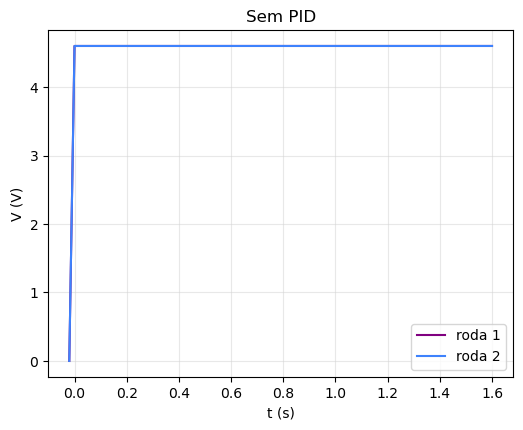

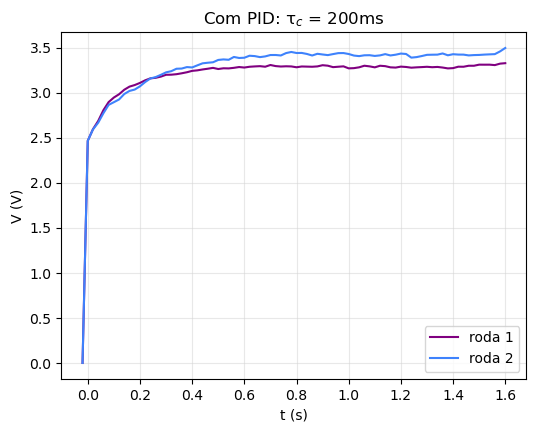

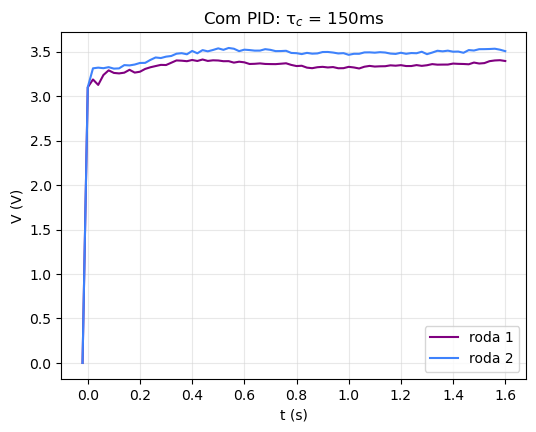

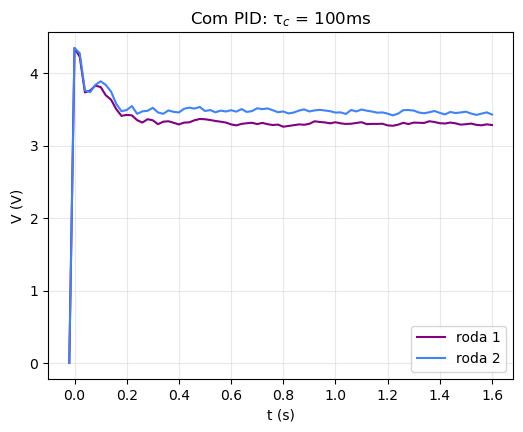

In [3]:
data = {} # dictionary to store data

for i, f in enumerate(files):
    d = np.loadtxt(data_dir / f).T # import data
    data[names[i]] = d # store in dictionary
    num = len(d[0]) # check size (must be 400)
    print(num)

    t = d[0]
    u1 = d[1]
    u2 = d[2]

    if PID_bol[i] == 0:
        d[3] /= V
        d[4] /= V

    # check voltage is correct

    fig_u, ax_u = plt.subplots(figsize = (6, 4.5))
    ax_u.plot(t[n_start[i] - 1:n_end[i]] - t[n_start[i]], u1[n_start[i] - 1:n_end[i]], color = plot_colors[0] , label = f'roda 1')
    ax_u.plot(t[n_start[i] - 1:n_end[i]] - t[n_start[i]], u2[n_start[i] - 1:n_end[i]], color = plot_colors[1] , label = f'roda 2')
    ax_u.grid(color = grid_color, alpha = 0.5)
    ax_u.set_xlabel('t (s)')
    ax_u.set_ylabel('V (V)')
    ax_u.set_title(names[i])
    ax_u.legend(loc = 'lower right')

    file_u_name = f'tensão_Com PID_tau={int(tau_ts[i - 1]*1000)}'

    if PID_bol[i] == 0: # if no PID we will determine it
        file_u_name = 'tensão_Sem PID'
        
    fig_u.savefig(im_dir/file_u_name, dpi = 200, bbox_inches = 'tight')

# Analysis
(com ajustes)

Sem PID
RODA 1
 - A = 5.31 (rad/s)/V
 - τ = 117 ms
RODA 2
 - A = 5.54 (rad/s)/V
 - τ = 114 ms
MÉDIA
 - A = 5.42 (rad/s)/V
 - τ = 115 ms
 - PID
     - para τ = 0.2
         - k_c = 0.106
         - k_i = 0.922
     - para τ = 0.15
         - k_c = 0.142
         - k_i = 1.229
     - para τ = 0.1
         - k_c = 0.213
         - k_i = 1.844
     - para τ = 0.08
         - k_c = 0.266
         - k_i = 2.304



Com PID: τ$_c$ = 200ms
RODA 1
 - A = 14.99 (rad/s)/V
 - τ = 193 ms
RODA 2
 - A = 15.08 (rad/s)/V
 - τ = 190 ms
MÉDIA
 - A = 15.03 (rad/s)/V
 - τ = 192 ms



Com PID: τ$_c$ = 150ms
RODA 1
 - A = 14.99 (rad/s)/V
 - τ = 146 ms
RODA 2
 - A = 15.01 (rad/s)/V
 - τ = 141 ms
MÉDIA
 - A = 15.00 (rad/s)/V
 - τ = 143 ms



Com PID: τ$_c$ = 100ms
RODA 1
 - A = 15.00 (rad/s)/V
 - τ = 93 ms
RODA 2
 - A = 15.02 (rad/s)/V
 - τ = 89 ms
MÉDIA
 - A = 15.01 (rad/s)/V
 - τ = 91 ms





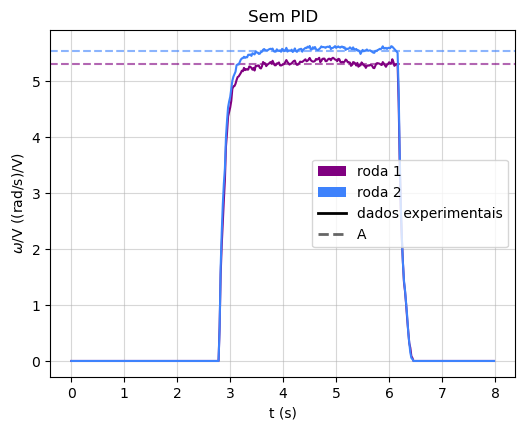

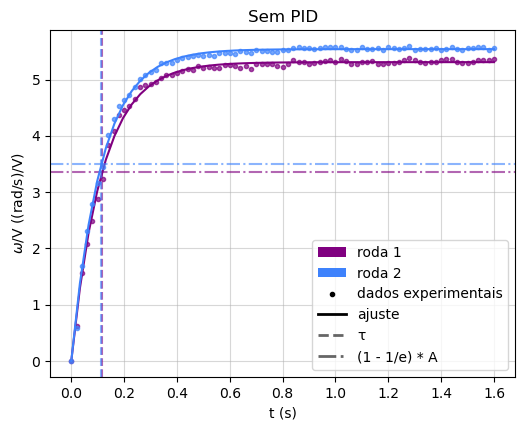

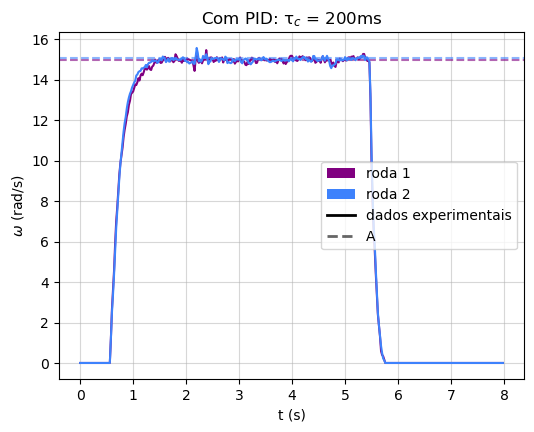

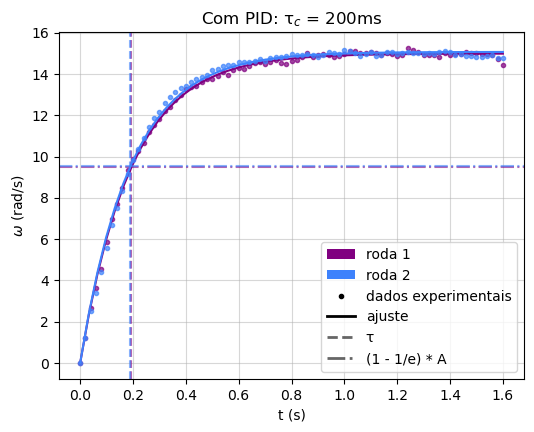

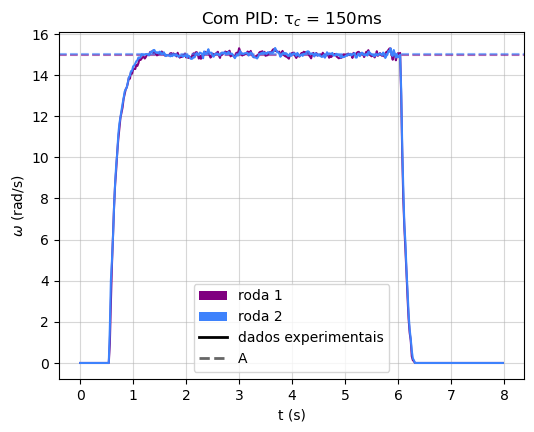

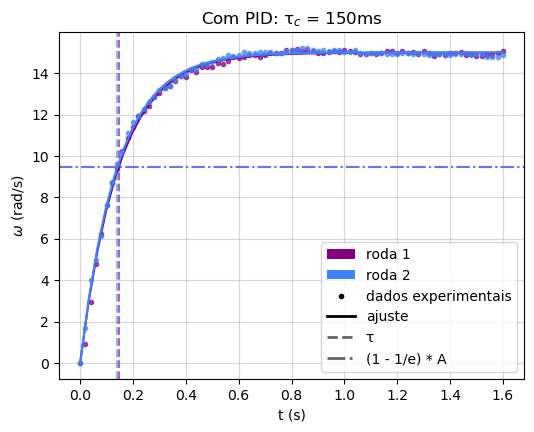

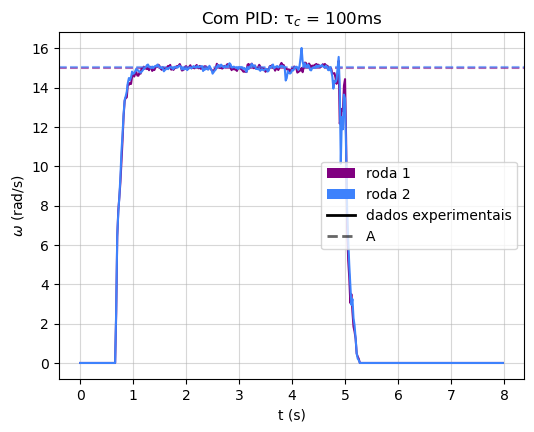

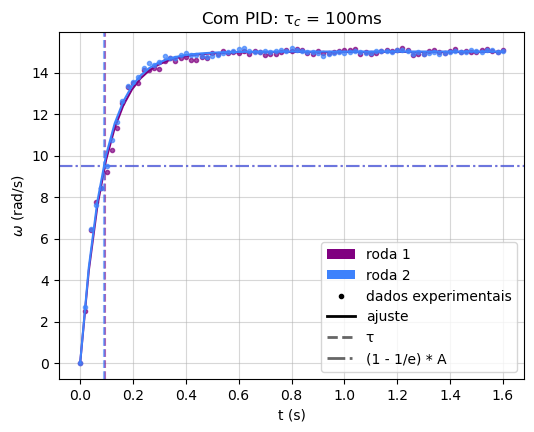

In [4]:
def wv (t, tau, A):
    return A * (1 - np.exp(-t/tau))

for i, key in enumerate(data):
    print(key)
    d = data[key]
    t = d[0]
    t_corr = t[n_start[i]:n_end[i]].copy()
    t_corr -= t_corr[0]
    w1 = d[3]
    w2 = d[4]
    ws = [w1, w2]

    # to store the values
    # kcs = np.zeros((len(tau_ts), 2))
    # kis = np.zeros((len(tau_ts), 2))
    As = np.zeros(2)
    taus = np.zeros(2)

    fig_og, ax_og = plt.subplots(figsize = (6, 4.5))
    ax_og.grid(grid_color, alpha = 0.5)
    ax_og.set_title(key)
    ax_og.set_xlabel('t (s)')
    if PID_bol[i] == 0:
        ax_og.set_ylabel(r'$\omega$/V ((rad/s)/V)')
    else:
        ax_og.set_ylabel(r'$\omega$ (rad/s)')
    
    motor_lines = [
        Patch(facecolor = plot_colors[k], edgecolor = 'none') for k in range(len(ws))
    ]
    motor_labels = [f'roda {k + 1}' for k in range(len(ws))]
    
    style_lines = [
        Line2D([0], [0], color = 'black', lw = 2, linestyle = '-'),
        Line2D([0], [0], color = 'black', lw = 2, linestyle = '--', alpha = 0.6)
    ]
    style_labels = ['dados experimentais', 'A']
    
    ax_og.legend(motor_lines + style_lines, motor_labels + style_labels)

    
    fig_f, ax_f = plt.subplots(figsize = (6, 4.5))
    ax_f.grid(grid_color, alpha = 0.5)
    ax_f.set_title(key)
    ax_f.set_xlabel('t (s)')
    if PID_bol[i] == 0:
        ax_f.set_ylabel(r'$\omega$/V ((rad/s)/V)')
    else:
        ax_f.set_ylabel(r'$\omega$ (rad/s)')
    motor_lines = [
        Patch(facecolor = plot_colors[k], edgecolor = 'none') for k in range(len(ws))
    ]
    motor_labels = [f'roda {k + 1}' for k in range(len(ws))]

    style_lines = [
        Line2D([0], [0], color = 'black', lw = 2, marker = '.', linestyle = 'None'),
        Line2D([0], [0], color = 'black', lw = 2, linestyle = '-'),
        Line2D([0], [0], color = 'black', lw = 2, linestyle = '--', alpha = 0.6),
        Line2D([0], [0], color = 'black', lw = 2, linestyle = '-.', alpha = 0.6)
    ]
    style_labels = ['dados experimentais', 'ajuste', 'τ', '(1 - 1/e) * A']
    
    ax_f.legend(motor_lines + style_lines, motor_labels + style_labels)
    
    
    for j, w in enumerate(ws):
        # dava pra simplificar isto tudo mas fiz mais tarde e tive preguiça
        w_corr = w[n_start[i]:n_end[i]]
        pars, cov = curve_fit(wv, t_corr, w_corr, maxfev=10000)
        taus[j], As[j] = pars
        A_tau = (1 - 1/np.e)*As[j]

        print(f"RODA {j + 1}\n - A = {As[j]:.2f} (rad/s)/V")
        print(f" - τ = {taus[j]*1000:.0f} ms")
            
        ax_og.plot(t, w, label = f'Roda {j + 1}', color = plot_colors[j])
        ax_og.axhline(As[j], linestyle = '--', color = plot_colors[j], alpha = 0.6)

        ax_f.plot(t_corr, w_corr, '.', color = plot_colors[j], alpha = 0.7)
        ax_f.plot(np.linspace(t_corr[0], t_corr[-1]), wv(np.linspace(t_corr[0], t_corr[-1]), *pars), color = plot_colors[j], label = f'Roda {j + 1}')
        ax_f.axvline(taus[j], linestyle = '--', color = plot_colors[j], alpha = 0.6)
        ax_f.axhline(A_tau, linestyle = '-.', color = plot_colors[j], alpha = 0.6)

    print("MÉDIA")
    A = np.mean(As)
    tau = np.mean(taus)
    print(f' - A = {A:.2f} (rad/s)/V')
    print(f" - τ = {tau*1000:.0f} ms")

    file_aj_name = f'ajuste_Com PID_tau={int(tau_ts[i - 1]*1000)}'
    file_all_name = f'all_Com PID_tau={int(tau_ts[i - 1]*1000)}'

    if PID_bol[i] == 0: # if no PID we will determine it
        file_aj_name = 'ajuste_Sem PID'
        file_all_name = 'all_Sem PID'
        
        print(' - PID')
        for k, tau_t in enumerate(tau_ts):
            print(f'     - para τ = {tau_t}')
            
            kc = tau/(tau_t * A)
            print(f"         - k_c = {kc:.3f}")
    
            ki = kc/tau
            print(f"         - k_i = {ki:.3f}")

    fig_f.savefig(im_dir/file_aj_name, dpi = 200, bbox_inches = 'tight')
    # fig_og.savefig(im_dir/file_all_name, dpi = 200, bbox_inches = 'tight')

    print('\n\n')